In [3]:
import time

import numpy as np
from sklearn.manifold import TSNE
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, models, transforms

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 1. Extract image embeddings from ResNet model trained in SimCLR notebook

Let's reload the model trained in self-supervised regime and explore its embeddings for the test set of `CIFAR10` dataset.

Let's apply dimensionality reduction and clustering to see how well clusters are defined. 

Let's also evaluate the clustering performance using the ground truth labels available for this dataset.

In [5]:
# helper function to extract embeddings from trained encoder
@torch.no_grad()
def get_model_embeddings(model, test_loader, device=torch.device("cpu")):
    all_labels = []
    all_embeddings = []
    model = model.eval().to(device)
    # now we are getting a single image from the model
    for img0, label in test_loader:
        img0 =  img0.to(device)
        emb = model.forward_embedding(img0)
        all_embeddings.append(emb.cpu().numpy())
        all_labels.append(label.numpy())
    all_embeddings = np.concatenate(all_embeddings, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return all_embeddings, all_labels

In [13]:
# we don't need paired dataset now, let's use standard dataset for CIFAR10 test set
class_labels = ("plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck")

dataset_trf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=0.5, std=0.25)
])
dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=dataset_trf)

batch_size = 128
test_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size)

Re-define the same model from the prev class

In [17]:
class ResnetModel(nn.Module):
    def __init__(self, projection_dim=128):
        super().__init__()
        # load model from torchvision.models with(!) pretrained weights.
        self.enc = models.resnet18(pretrained=False)
        self.feature_dim = self.enc.fc.in_features

        # Customize for CIFAR10. Replace conv 7x7 with conv 3x3, and remove first max pooling.
        # See Section B.9 of SimCLR paper.
        self.enc.conv1 = nn.Conv2d(3, 64, 3, 1, 1, bias=False)
        self.enc.maxpool = nn.Identity()
        self.enc.fc = nn.Identity()  # remove final fully connected layer.

        # Add MLP projection.
        self.projection_dim = projection_dim
        self.projector = nn.Sequential(nn.Linear(self.feature_dim, 2048),
                                       nn.ReLU(),
                                       nn.Linear(2048, projection_dim))

    def forward_embedding(self, x):
        emb = self.enc(x)
        return emb

    def forward(self,x):
        emb = self.enc(x)
        projection = self.projector(emb)
        return emb, projection

Load the weights

In [18]:
checkpoint_path = "cifar10_simclr_resnet18_final.ckpt"
model_dict = torch.load(checkpoint_path)
state_dict = model_dict['model_state_dict']
model = ResnetModel()
model.load_state_dict(state_dict)

<All keys matched successfully>

In [23]:
test_embeddings, all_labels = get_model_embeddings(model, test_loader, device=device)
test_embeddings.shape, all_labels.shape

((10000, 512), (10000,))

## 2. tSNE visualization

We can now visualize the distribution of the embeddings using t-SNE method from scikit learn and see if there is any neighbor structure and class separation for the trained model.

In [21]:
tsne = TSNE(n_components=2, )
test_2dim = tsne.fit_transform(test_embeddings) 

Let's split the classes in two plots for better visualization

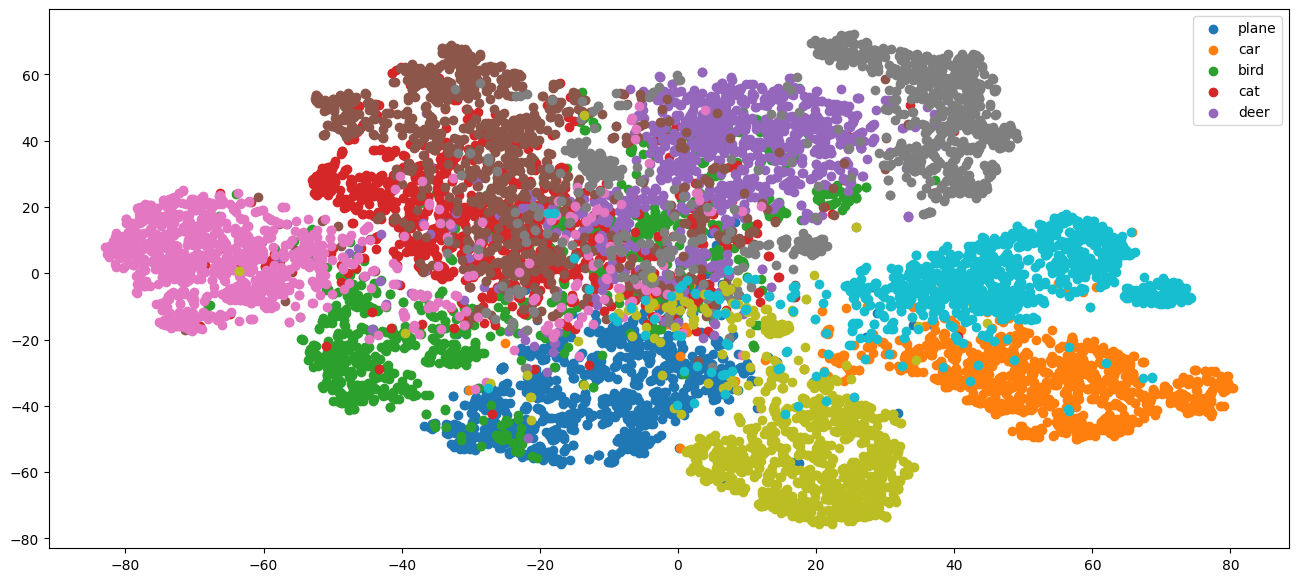

In [28]:
# re-define these for more detailed visualization
all_class_indices = list(range(len(class_labels)))
fig, ax = plt.subplots(1, 1, figsize=(16, 7))
for class_idx in all_class_indices:
    class_mask = all_labels == class_idx
    ax.scatter(test_2dim[class_mask, 0], test_2dim[class_mask, 1])
ax.legend([class_labels[class_idx] for class_idx in first_class_index_list])
plt.show()

 We see there is a decent class separation for testing set, but tSNE is a method of visualization and not a clustering method. 

 Let's apply some clustering approaches to this data and evaluate the performance.

 ## 3. Clustering metrics

There are two metrics for clustering performance evaluation which we are going to use:
- [Adjusted Rand Score (ARI)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html): helps to measure how well at least some clusters correspond to the ground-truth clusters (labels) considering all possible combinations of ground-truth and predicted cluster indices.
- [Normalized Mutual Information Score (NMI)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.normalized_mutual_info_score.html) - helps measure the correlation between cluster indices and ground truth cluster labels, but not normalized by chance. Ranges from 1.0 (perfect correlation) to 0.0 (no correlation). May have increased value for small clusters, so ARI is preferred.

Let's also utilize optuna for hyperparameter search instead of manual parameter grid selection

In [32]:
# uncomment the line below to install optuna
# !pip install optuna

### 3.1 Let's first try KMeans on non-processed data

In [84]:
import optuna
from optuna.samplers import TPESampler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.pipeline import Pipeline

In [85]:
random_state = 42
def objective_kmeans(trial):
    cluster_pipeline = Pipeline([
        (
            'pca',
            PCA(n_components=trial.suggest_float("pca__n_components", 0.9, 1.0), random_state=random_state)),
        (
            'cluster',
            KMeans(n_clusters=trial.suggest_int("cluster__n_clusters", 2, 20), random_state=random_state)
        )
    ])
    y_pred = cluster_pipeline.fit_predict(test_embeddings)
    ari_score = adjusted_rand_score(all_labels, y_pred)
    return ari_score

sampler = TPESampler(seed=123)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective_kmeans, n_trials=20)

[I 2025-12-18 14:46:12,420] A new study created in memory with name: no-name-ba754286-e6ef-4266-a07d-dad919c51a79
[I 2025-12-18 14:46:12,551] Trial 0 finished with value: 0.21521272785683887 and parameters: {'pca__n_components': 0.9696469185597861, 'cluster__n_clusters': 7}. Best is trial 0 with value: 0.21521272785683887.
[I 2025-12-18 14:46:12,691] Trial 1 finished with value: 0.1792936552271945 and parameters: {'pca__n_components': 0.9226851453564203, 'cluster__n_clusters': 12}. Best is trial 0 with value: 0.21521272785683887.
[I 2025-12-18 14:46:12,834] Trial 2 finished with value: 0.15667915374636007 and parameters: {'pca__n_components': 0.9719468969785563, 'cluster__n_clusters': 10}. Best is trial 0 with value: 0.21521272785683887.
[I 2025-12-18 14:46:13,105] Trial 3 finished with value: 0.23127161343932726 and parameters: {'pca__n_components': 0.9980764198384615, 'cluster__n_clusters': 15}. Best is trial 3 with value: 0.23127161343932726.
[I 2025-12-18 14:46:13,307] Trial 4 fini

In [86]:
print(study.best_params)
cluster_pipeline_best = Pipeline([
    ('pca', PCA(random_state=random_state)),
    ('cluster', KMeans(random_state=random_state))
])
cluster_pipeline_best.set_params(**study.best_params)
y_pred = cluster_pipeline_best.fit_predict(test_embeddings)
ari_score = adjusted_rand_score(y_test, y_pred)
nmi_score = normalized_mutual_info_score(y_test, y_pred)
print(f"best ARI score: {ari_score:.4f}")
print(f"best NMI score: {nmi_score:.4f}")

{'pca__n_components': 0.9990160103627941, 'cluster__n_clusters': 16}
best ARI score: 0.2642
best NMI score: 0.5683


Let's reuse 2dimensional embeddings from tSNE visualization above so we can better visualize assigned cluster indices

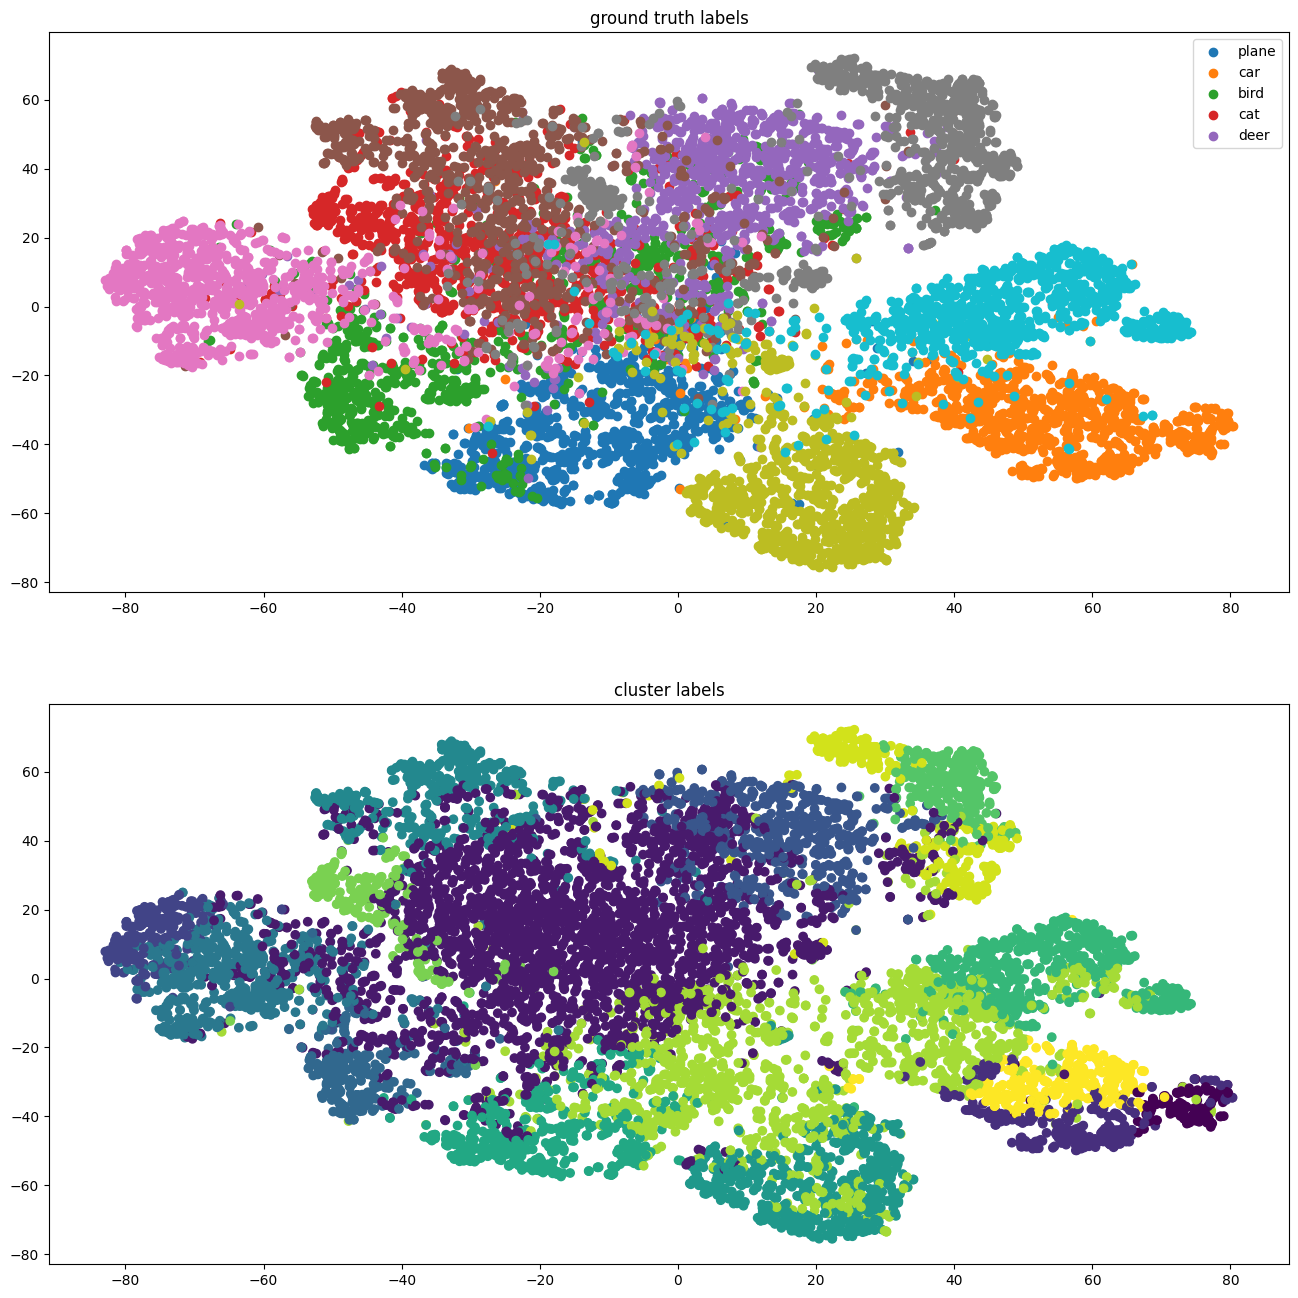

In [87]:
all_class_indices = list(range(len(class_labels)))
fig, ax = plt.subplots(2, 1, figsize=(16, 16))
for class_idx in all_class_indices:
    class_mask = all_labels == class_idx
    ax[0].scatter(test_2dim[class_mask, 0], test_2dim[class_mask, 1])
    ax[0].set_title("ground truth labels")
ax[0].legend([class_labels[class_idx] for class_idx in first_class_index_list])
ax[1].scatter(test_2dim[:, 0], test_2dim[:, 1], c=y_pred)
ax[1].set_title("cluster labels")
plt.show()

We may find that *some* of the assigned clusters closely match the original labels, which is nice

Let's now utilize a more powerful way to cluster NN embeddings: a combination of UMAP and HDBSCAN!

### 3.2 UMAP + HDBSCAN

Applying UMAP before searching for clusters allow to reduce embedding dimensions and fight the dimensionality curse and thus improve clustering ability of HDBSCAN. The latter also has a nice property of not having to manually tune the number of clusters

In [61]:
# uncomment to install UMAP
# !pip install umap-learn

ERROR: Could not find a version that satisfies the requirement umap (from versions: none)
ERROR: No matching distribution found for umap


In [63]:
import umap
from sklearn.cluster import HDBSCAN

In [88]:
random_state = 42
def objective_hdbscan(trial):
    cluster_pipeline = Pipeline([
        (
            'reducer',
            umap.UMAP(
                n_components=trial.suggest_int("reducer__n_components", 16, 128),
                n_neighbors=trial.suggest_int("reducer__n_neighbors", 5, 128),
                learning_rate=trial.suggest_float("reducer__learning_rate", 0.1, 1.0),
                random_state=random_state
            )
        ),
        (
            'cluster',
            HDBSCAN(
                min_cluster_size=trial.suggest_int("cluster__min_cluster_size", 5, 64)
            )
        )
    ])
    y_pred = cluster_pipeline.fit_predict(test_embeddings)
    ari_score = adjusted_rand_score(all_labels, y_pred)
    return ari_score

sampler = TPESampler(seed=123)
study_dbscan = optuna.create_study(direction='maximize', sampler=sampler)
# tune param a bit longer because model complexity is now increased
study_dbscan.optimize(objective_hdbscan, n_trials=30)

[I 2025-12-18 14:46:43,289] A new study created in memory with name: no-name-2618f818-e8fc-4b60-8a4e-1b530ad940ba
/home/iefimov/miniconda3/envs/nerfstudio/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
[I 2025-12-18 14:47:26,514] Trial 0 finished with value: 0.29353240488553034 and parameters: {'reducer__n_components': 94, 'reducer__n_neighbors': 40, 'reducer__learning_rate': 0.3041663082077828, 'cluster__min_cluster_size': 38}. Best is trial 0 with value: 0.29353240488553034.
/home/iefimov/miniconda3/envs/nerfstudio/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
[I 2025-12-18 14:48:07,803] Trial 1 finished with value: 0.28797412551953633 and parameters: {'reducer__n_components': 97, 'reducer__n_neighbors': 57, 'reducer__learning_rate': 0.982687778546154, 'cluster__min_cluste

In [90]:
print("found best params")
print(study_dbscan.best_params)
cluster_pipeline_best = Pipeline([
    ('reducer', umap.UMAP()),
    ('cluster', HDBSCAN())
])
cluster_pipeline_best.set_params(**study_dbscan.best_params)
y_pred = cluster_pipeline_best.fit_predict(test_embeddings)
ari_score = adjusted_rand_score(y_test, y_pred)
nmi_score = normalized_mutual_info_score(y_test, y_pred)
print(f"best ARI score: {ari_score:.4f}")
print(f"best NMI score: {nmi_score:.4f}")

found best params
{'reducer__n_components': 39, 'reducer__n_neighbors': 33, 'reducer__learning_rate': 0.5394490956397513, 'cluster__min_cluster_size': 32}
best ARI score: 0.2746
best NMI score: 0.5709


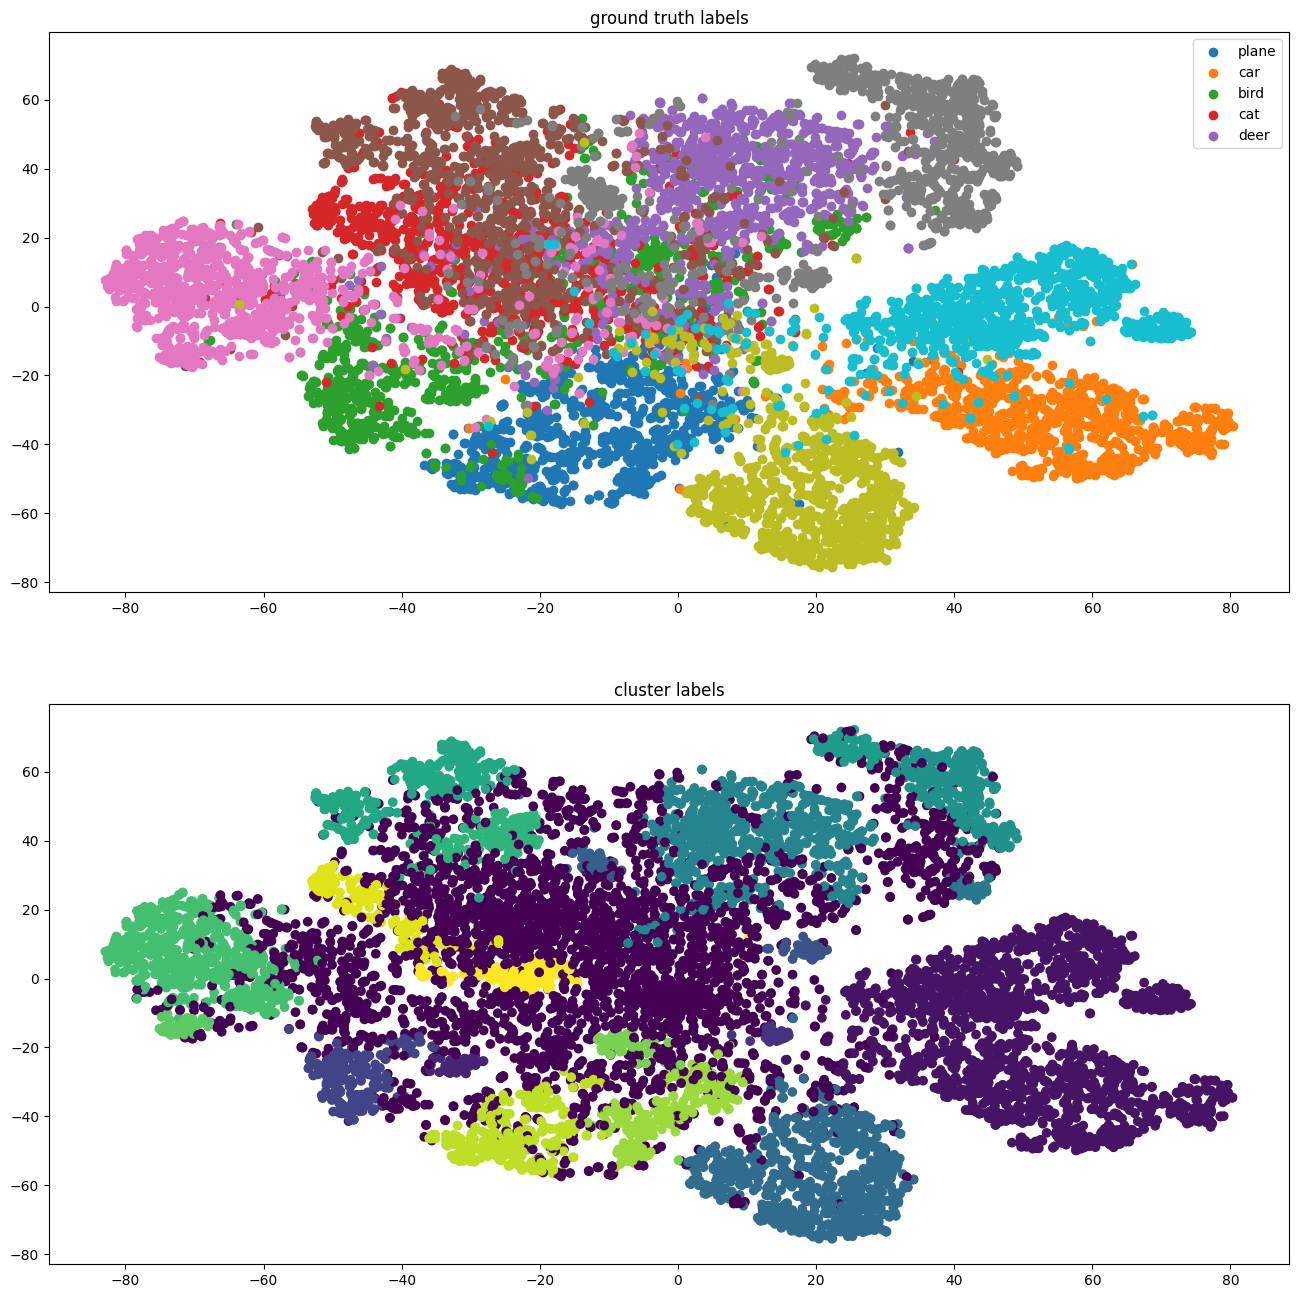

In [91]:
all_class_indices = list(range(len(class_labels)))
fig, ax = plt.subplots(2, 1, figsize=(16, 16))
for class_idx in all_class_indices:
    class_mask = all_labels == class_idx
    ax[0].scatter(test_2dim[class_mask, 0], test_2dim[class_mask, 1])
    ax[0].set_title("ground truth labels")
ax[0].legend([class_labels[class_idx] for class_idx in first_class_index_list])
ax[1].scatter(test_2dim[:, 0], test_2dim[:, 1], c=y_pred)
ax[1].set_title("cluster labels")
plt.show()